In [ ]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
import os
import optuna
import os
import time
import statistics

from optuna.visualization import (
    plot_optimization_history,
    plot_intermediate_values,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour,
    plot_slice,
    plot_edf,
    plot_rank,
    plot_timeline,
)

sys.path.insert(0, str(Path.cwd()))

from core.dataset  import DatasetLoader
from core.tuner    import GNNTuner
from core.config   import TrainingConfig, EarlyStoppingConfig, SchedulerConfig, SplitConfig, IOConfig, ModelConfig

sys.path.insert(0, r"C:\Users\Victo\OneDrive\Área de Trabalho\dune\dune_gnn_v1")

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
io = IOConfig()

%load_ext tensorboard
%tensorboard --logdir {io.logdir} --port 6014 --reload_interval 30

In [3]:
split_config = SplitConfig(
    test_size=0.1,
    val_ratio=0.1,
    random_state=42
)

In [4]:
dataset_path = dataset_dir = f"./datasets/E_10.0MeV/k_5/bi_True/close_i_4_rbf_8_inactive_r_2.0"

In [5]:
loader = DatasetLoader(preprocessed_dir=dataset_path, split_config=split_config)

train_dataset, val_dataset, test_dataset, norm_metrics = loader.load_dataset()
config_dict = loader.load_config()

2025-12-22 02:49:53,607 - DatasetNormalizer - INFO -   Node statistics: mean shape=(12,), std shape=(12,)
2025-12-22 02:50:00,066 - DatasetNormalizer - INFO -   Edge statistics: mean shape=(12,), std shape=(12,)
2025-12-22 02:50:00,334 - DatasetNormalizer - INFO -   Target statistics: mean shape=(3,), std shape=(3,)
2025-12-22 02:50:00,335 - DatasetNormalizer - INFO -   Computed statistics from 'train' split
2025-12-22 02:50:05,711 - DatasetLoader - INFO -   SplitConfig used: test_size=0.1, val_ratio=0.1, random_state=42
2025-12-22 02:50:05,711 - DatasetLoader - INFO -   Dataset split: train=7583(81%) | val=842(9%) | test=936(10%)
2025-12-22 02:50:05,711 - DatasetLoader - INFO -   Normalized using 'train' metrics
2025-12-22 02:50:05,711 - DatasetLoader - INFO -   Node statistics (train): mean=[ 0.67240816 -0.84528816  4.0818186   0.21246485  0.22175777  0.9721591
 17.843815   -1.1671573   2.3287954  -2.4382534   1.1735213  11.864999  ], std=[ 3.502379    6.279843   19.090786    0.46930

In [6]:
print("\nDataset splits:")
print(f"  Training:   {len(train_dataset)} graphs")
print(f"  Validation: {len(val_dataset)} graphs")
print(f"  Test:       {len(test_dataset)} graphs")

sample_graph = train_dataset[0]
print(f"\nSample graph structure:")
print(f"  Node features (x): {sample_graph.x.shape}")
print(f"  Edge indices: {sample_graph.edge_index.shape}")
print(f"  Target coordinates (y): {sample_graph.y.shape}")
print(f"  Target values: {sample_graph.y.numpy()}")


Dataset splits:
  Training:   7583 graphs
  Validation: 842 graphs
  Test:       936 graphs

Sample graph structure:
  Node features (x): torch.Size([921, 12])
  Edge indices: torch.Size([2, 5566])
  Target coordinates (y): torch.Size([1, 3])
  Target values: [[-0.14895074  0.53158605 -0.90239966]]


In [7]:
num_nodes = [graph.x.shape[0] for graph in train_dataset + val_dataset + test_dataset]
num_edges = [graph.edge_index.shape[1] for graph in train_dataset + val_dataset + test_dataset]

print(f"\nGraph topology statistics (all splits):")
print(f"  Node count per graph:")
print(f"    Range: [{min(num_nodes)}, {max(num_nodes)}]")
print(f"    Mean: {np.mean(num_nodes):.2f}")
print(f"    Standard deviation: {np.std(num_nodes):.2f}")

print(f"\n  Edge count per graph:")
print(f"    Range: [{min(num_edges)}, {max(num_edges)}]")
print(f"    Mean: {np.mean(num_edges):.2f}")
print(f"    Standard deviation: {np.std(num_edges):.2f}")
print(f"    Mean degree: {np.mean(num_edges)/np.mean(num_nodes):.2f}")


Graph topology statistics (all splits):
  Node count per graph:
    Range: [308, 2046]
    Mean: 1171.39
    Standard deviation: 352.67

  Edge count per graph:
    Range: [1868, 12114]
    Mean: 7029.56
    Standard deviation: 2100.01
    Mean degree: 6.00


In [8]:
training_config = TrainingConfig(
    lr=5e-4,
    weight_decay=1e-5,
    batch_size=128,
    epochs=300,
    log_dir=io.logdir,
    writer=io.writer,
    deep_log=False
)

In [ ]:
batch_size = training_config.batch_size
num_workers = 8

loader_kwargs = dict(
    batch_size=batch_size,
    pin_memory=True,
    num_workers=num_workers,
)

if num_workers > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2
else:
    loader_kwargs["persistent_workers"] = False

train_loader = DataLoader(train_dataset, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_kwargs)

In [19]:
early_stopping_config = EarlyStoppingConfig(
    patience=8,
    min_delta=1e-4,
    restore_best=True
)

scheduler_config = SchedulerConfig(
    factor=0.6,
    patience=5,
    mode="min"
)

model_config = ModelConfig(
    input_dim=12,
    output_dim=3,
    edge_dim=12
)

In [20]:
tuner = GNNTuner(model_config=model_config, early_stopping_config = early_stopping_config, scheduler_config = scheduler_config, tuning_epochs=30, seed=42, log_dir=io.logdir, norm_metrics=norm_metrics, num_workers=num_workers)
tuner.optimize(train_dataset, val_dataset, n_trials=10)
study = tuner.optimizer.study

  0%|          | 0/10 [00:00<?, ?it/s]

Trial 5 pruned at epoch 6 with validation loss 0.030635.
Trial 6 pruned at epoch 6 with validation loss 0.028260.
Trial 7 pruned at epoch 6 with validation loss 0.028341.
Trial 8 pruned at epoch 6 with validation loss 0.039531.
[W 2025-12-22 11:01:44,240] Trial 9 failed with parameters: {'gcn_hidden_0': 256, 'gcn_hidden_1': 256, 'mlp_hidden_0': 128, 'mlp_hidden_1': 256, 'dropout': 0.1, 'attention_heads': 8, 'lr': 0.0001021045111451298, 'weight_decay': 2.390515970428683e-05} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Victo\anaconda3\envs\DeepGPU\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "c:\Users\Victo\OneDrive\Área de Trabalho\dune\dune_gnn\core\tuner.py", line 148, in <lambda>
    self.study.optimize(
                      ^^^
  File "c:\Users\Victo\OneDrive\Área de Trabalho\dune\dune_gnn\core\tuner.py", line 105, in _obje

KeyboardInterrupt: 

In [23]:
study = tuner.study

C:\Users\Victo\AppData\Local\Temp\ipykernel_10112\1782258544.py:25: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\Victo\AppData\Local\Temp\ipykernel_10112\1782258544.py:25: ExperimentalWarning: optuna.visualization.matplotlib._intermediate_values.plot_intermediate_values is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\Victo\AppData\Local\Temp\ipykernel_10112\1782258544.py:25: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\Victo\AppData\Local\Temp\ipykernel_10112\1782258544.py:25: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0).

[warn] failed 'contour': 'numpy.ndarray' object has no attribute 'figure'
[warn] failed 'slice': 'numpy.ndarray' object has no attribute 'figure'


C:\Users\Victo\AppData\Local\Temp\ipykernel_10112\1782258544.py:25: ExperimentalWarning: optuna.visualization.matplotlib._edf.plot_edf is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


Saved 5 PNG(s) to: c:\Users\Victo\OneDrive\Área de Trabalho\dune\dune_gnn\runs\run_20251222-024937


['runs/run_20251222-024937\\optimization_history.png',
 'runs/run_20251222-024937\\intermediate_values.png',
 'runs/run_20251222-024937\\param_importances.png',
 'runs/run_20251222-024937\\parallel_coordinate.png',
 'runs/run_20251222-024937\\edf.png']

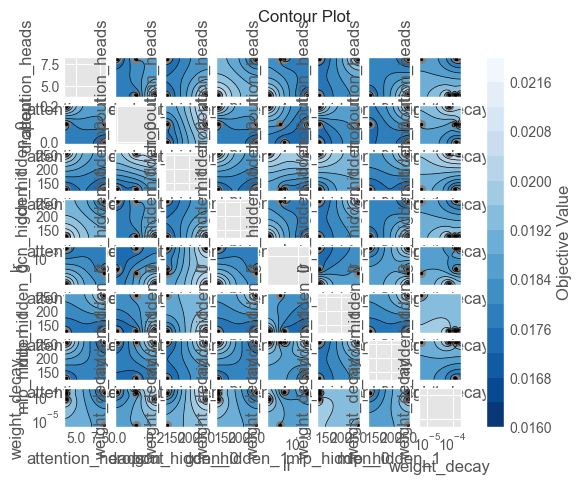

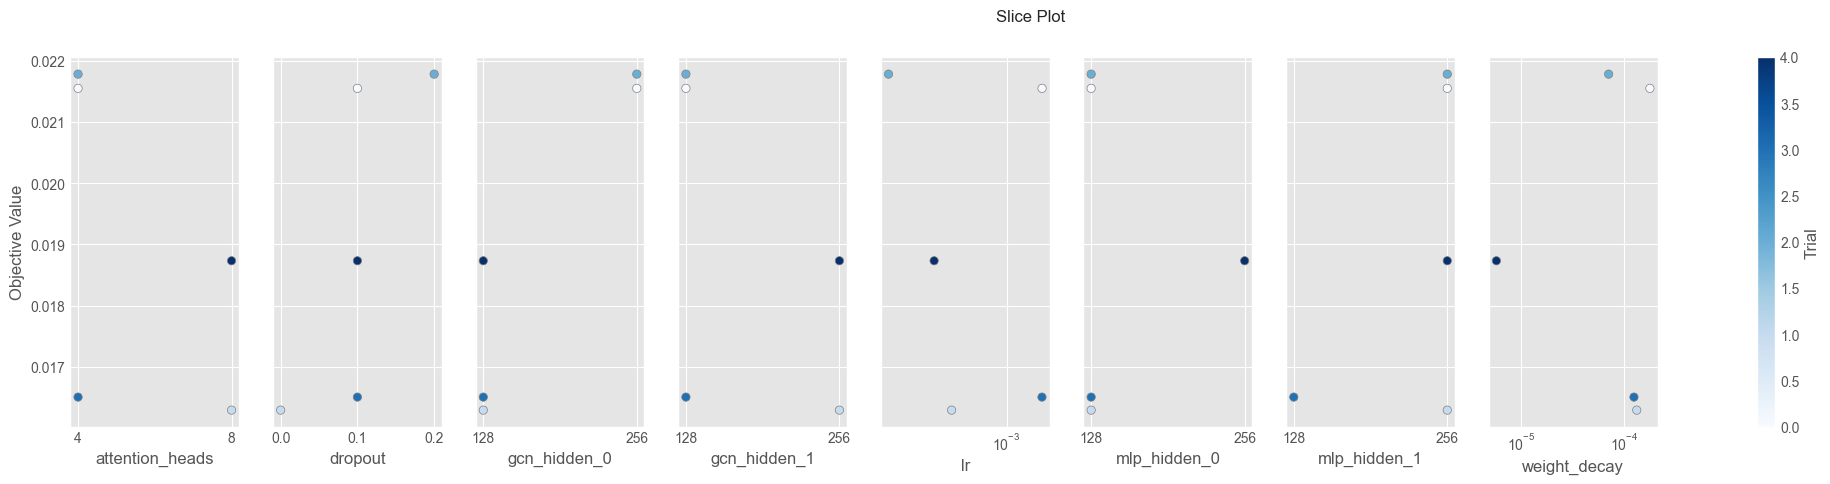

In [24]:
def save_optuna_pngs(
    study: optuna.Study,
    out_dir = None,
    dpi: int = 150,
):

    if out_dir is None:
        main_mod = sys.modules.get("__main__")
        out_dir = getattr(getattr(main_mod, "io", None), "logdir", None) or "optuna_reports"
    os.makedirs(out_dir, exist_ok=True)

    plots = {
        "optimization_history": optuna.visualization.matplotlib.plot_optimization_history,
        "intermediate_values": optuna.visualization.matplotlib.plot_intermediate_values,  # needs trial.report(...)
        "param_importances": optuna.visualization.matplotlib.plot_param_importances,
        "parallel_coordinate": optuna.visualization.matplotlib.plot_parallel_coordinate,
        "contour": optuna.visualization.matplotlib.plot_contour,
        "slice": optuna.visualization.matplotlib.plot_slice,
        "edf": optuna.visualization.matplotlib.plot_edf,
    }

    saved = []
    for name, fn in plots.items():
        try:
            ax = fn(study)
            if ax is None:
                continue
            fig = ax.figure
            fig.tight_layout()
            path = os.path.join(out_dir, f"{name}.png")
            fig.savefig(path, dpi=dpi)  
            plt.close(fig)
            saved.append(path)
        except Exception as exc:
            print(f"[warn] failed '{name}': {exc}")

    print(f"Saved {len(saved)} PNG(s) to: {os.path.abspath(out_dir)}")
    return saved

save_optuna_pngs(study, dpi=200)   

In [25]:
plot_optimization_history(study)

In [26]:
plot_intermediate_values(study)

In [27]:
plot_param_importances(study)

In [28]:
plot_parallel_coordinate(study)

In [29]:
plot_contour(study)

In [30]:
plot_slice(study)

In [31]:
plot_edf(study)

In [32]:
plot_rank(study)

In [33]:
plot_timeline(study)